In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [22]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)
blacks = sns.light_palette('black', as_cmap=True)
recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

'notebook'

# Load HGA

In [25]:
# load zscore to get electrode coordinates
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 738/738 [00:07<00:00, 102.54it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [26]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 219520
PIC electrode count: 184960


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [27]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [28]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

# Load significant RT results

In [23]:
ref = 'bipolar'
tasks = ['LexicalDelay', 'PhonemeSequence']

rt = []

for task in tasks:
    result_path = BIDSPath(
        datatype='RT',
        root=f'../results/{task}({ref})',
        suffix='highgamma',
        check=False
    )

    full_path = result_path.match()
    if not full_path:
        print(f'No RT results found for {task}, skipping.')
        continue

    for path in tqdm(full_path, desc=task):
        mat = h5py.File(path, 'r')
        
        # r2: (channels, time)
        r2 = mat['score'][()]
        
        pearsonr = mat['score'][()]
        # time: (time,)
        time = mat['time'][()]
        # channels: (channels,)
        channels = [ch.decode('utf-8') for ch in mat['channels'][:]]
        # pval: (channels, time)
        pval = mat['pval'][()]
        # perm_r2: (channels, time, n_perm)
        perm_r2 = mat['perm_r2'][()]
        # cluster_pval: (channels, time)
        cluster_pval = mat['cluster_pval'][()]
        # mask: (channels, time)
        mask = mat['mask'][()]
        
        mat.close()
        
        n_channels, n_time = r2.shape
        
        # ---- 1) perm_r2 在 perm 维度上平均 → (channels, time) ----
        perm_r2_mean = perm_r2.mean(axis=-1)  # shape: (channels, time)
        
        # ---- 2) 宽表：每列一个 time point（r2）----
        df_r2 = pd.DataFrame(r2, index=channels, columns=time).reset_index()
        df_r2 = df_r2.rename(columns={'index': 'channel'})
        
        # 宽表 perm_r2_mean
        df_perm = pd.DataFrame(perm_r2_mean, index=channels, columns=time).reset_index()
        df_perm = df_perm.rename(columns={'index': 'channel'})
        
        # 宽表 pval
        df_pval = pd.DataFrame(pval, index=channels, columns=time).reset_index()
        df_pval = df_pval.rename(columns={'index': 'channel'})
        
        # 宽表 cluster_pval
        df_cluster_pval = pd.DataFrame(cluster_pval, index=channels, columns=time).reset_index()
        df_cluster_pval = df_cluster_pval.rename(columns={'index': 'channel'})
        
        # 宽表 mask
        df_mask = pd.DataFrame(mask, index=channels, columns=time).reset_index()
        df_mask = df_mask.rename(columns={'index': 'channel'})
        
        # ---- 3) 宽 → 长，显式保留 channel ----
        df_r2 = df_r2.melt(id_vars='channel', var_name='time', value_name='r2')
        df_perm = df_perm.melt(id_vars='channel', var_name='time', value_name='perm_r2_mean')
        df_pval = df_pval.melt(id_vars='channel', var_name='time', value_name='pval')
        df_cluster_pval = df_cluster_pval.melt(id_vars='channel', var_name='time', value_name='cluster_pval')
        df_mask = df_mask.melt(id_vars='channel', var_name='time', value_name='mask')
        
        # 合并所有指标（按 channel, time 对齐）
        df = df_r2.merge(df_perm, on=['channel', 'time'], how='left')
        df = df.merge(df_pval, on=['channel', 'time'], how='left')
        df = df.merge(df_cluster_pval, on=['channel', 'time'], how='left')
        df = df.merge(df_mask, on=['channel', 'time'], how='left')
        
        # ---- 4) 加上 path 的元信息 ----
        df['subject'] = path.subject
        df['phase'] = path.processing
        df['description'] = path.description
        df['band'] = path.suffix
        df['task'] = task
        
        rt.append(df)

rt = pd.concat(rt, ignore_index=True)
print(f'Total rows: {len(rt):,}')
print(f'Tasks: {rt.task.unique().tolist()}')
print(f'Subjects per task:')
print(rt.groupby('task')['subject'].nunique())
rt.head()

PhonemeSequence: 100%|██████████| 180/180 [00:07<00:00, 23.65it/s]


Total rows: 1,570,756
Tasks: ['LexicalDelay', 'PhonemeSequence']
Subjects per task:
task
LexicalDelay       40
PhonemeSequence    45
Name: subject, dtype: int64


,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band,task
0,D0023_RMSF9-10,-0.8,0.088125,-0.005343,0.209581,0.209581,False,D0023,Delay,Decision,highgamma,LexicalDelay
1,D0023_RMSF10-11,-0.8,-0.100959,0.001421,0.872255,0.872255,False,D0023,Delay,Decision,highgamma,LexicalDelay
2,D0023_RPSF1-2,-0.8,-0.182163,-0.004423,0.978044,0.978044,False,D0023,Delay,Decision,highgamma,LexicalDelay
3,D0023_RPSF5-6,-0.8,-0.072658,-0.004403,0.788423,0.788423,False,D0023,Delay,Decision,highgamma,LexicalDelay
4,D0023_RPSF8-9,-0.8,0.184029,0.005443,0.019960,0.019960,False,D0023,Delay,Decision,highgamma,LexicalDelay


In [24]:
# 1. Has to be HGA significant
coords = (
    HGAs[['channel', 'roi', 'label', 'hemi', 'x', 'y', 'z']]
    .drop_duplicates()
    .reset_index(drop=True)
)

sig_channels = coords.channel.tolist()

rt_ = rt[rt.channel.isin(sig_channels)]
rt_ = rt_.merge(coords, on='channel', how='left')

# remove all the irrelevant roi
exclude_list = ['mOccG','OPC','Hipp','Central','Put',
                'PhG','GRect','LinGs','CollatAnt','LinG',
                'Amyg','LatV','InfLatV','PCun','CC_Central(unknown)',
                'Cun','VDC','BrainStem(unknown)','Intersection','OFCs',
                'iOccGs','Calcarine','Thal','OccS','FuGs','Paracentral',
                'PCuns',
                'SFGs','MFGs','IFGs','CGs',
                ]

rt_ = rt_[~rt_.roi.isin(exclude_list)]
# only take sig rt out

delay_mask = (
    (rt_['phase'] == 'Delay') &
    (rt_['time'] >= 0.0) &
    (rt_['time'] <= 0.8) &
    (rt_['mask'] == True)
)
 
# Go 窗口 [-0.5, 0]
go_mask = (
    (rt_['phase'] == 'Go') &
    (rt_['time'] >= -0.5) &
    (rt_['time'] <= 1) &
    (rt_['mask'] == True)
)

resp_mask = (
    (rt_['phase'] == 'Response') &
    (rt_['time'] >= -0.5) &
    (rt_['time'] <= 1) &
    (rt_['mask'] == True)
)

sig_channels = list(
    set(rt_.loc[delay_mask, 'channel'].unique()) |
    set(rt_.loc[go_mask, 'channel'].unique()) |
    set(rt_.loc[resp_mask, 'channel'].unique())
)

rt_subset = rt_[rt_.channel.isin(sig_channels)]

# only keep repeat condition
rt_subset = rt_subset[rt_subset['description'] == 'Repeat']
rt_subset.head()

,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band,task,roi,label,hemi,x,y,z
2091,D0023_RPSF12-13,-0.8,0.157784,0.002827,0.021956,0.021956,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SFG,ctx_rh_G_front_sup,R,16.851658,10.116029,46.261659
2095,D0023_R2MF9-10,-0.8,0.083599,-0.001525,0.197605,0.197605,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SMC,ctx_rh_S_precentral-inf-part,R,37.198654,8.491999,17.194256
2096,D0023_R2MF10-11,-0.8,0.015989,-0.002759,0.379242,0.379242,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SMC,ctx_rh_S_precentral-inf-part,R,40.806408,8.426507,17.194175
2097,D0023_RPMF1-2,-0.8,0.203528,0.001042,0.003992,0.003992,True,D0023,Delay,Repeat,highgamma,LexicalDelay,CG,ctx_rh_G_and_S_cingul-Mid-Post,R,8.111536,-1.541567,17.064693
2098,D0023_RPMF2-3,-0.8,0.201600,-0.000403,0.009980,0.009980,True,D0023,Delay,Repeat,highgamma,LexicalDelay,CG,ctx_rh_G_and_S_cingul-Mid-Post,R,11.216092,-2.070248,17.107585


# A pie chart to show the portion

In [69]:
# 1. 筛选 significant 的电极
rt_phase = rt_subset[rt_subset.phase=='Delay']

sig_channels = rt_phase.loc[rt_phase['mask'], 'channel'].unique()
rt_phase = rt_phase[rt_phase['channel'].isin(sig_channels)].copy()

subset = rt_phase.copy()
# 3. 筛选动态范围在 [-1, 1] 且 max > 0 的电极
g = subset.groupby('channel')['r2']

picks = (
    g.min().ge(-1) &   
    g.max().le(1) &    
    g.max().gt(0)      
)
picks = picks[picks].index  

print(f"原始 significant 电极数: {len(sig_channels)}")
print(f"phase 中满足条件的电极数: {len(picks)}")

# 只保留满足条件的电极
subset = subset[subset.channel.isin(picks)].copy()

# 聚合坐标信息
coords_ = subset.groupby('channel').agg({
    'r2': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
}).reset_index()

# coords_ = coords_[coords_['r2'] > 0.1]

# 验证筛选结果
print("\n筛选后的 R² 统计:")
print(f"  Min: {coords_['r2'].min():.4f}")
print(f"  Max: {coords_['r2'].max():.4f}")
print(f"  每个 channel 的 max:")
channel_max = coords_.groupby('channel')['r2'].max()
print(f"    所有 channel 的 max 都 > 0: {(channel_max > 0).all()}")
print(f"    Max 的范围: [{channel_max.min():.4f}, {channel_max.max():.4f}]")

coords_.head()

原始 significant 电极数: 301
phase 中满足条件的电极数: 301

筛选后的 R² 统计:
  Min: -0.0752
  Max: 0.2998
  每个 channel 的 max:
    所有 channel 的 max 都 > 0: False
    Max 的范围: [-0.0752, 0.2998]


,channel,r2,x,y,z,roi,label,phase,hemi,subject
0,D0023_R2IF1-2,0.000077,33.870455,8.658320,-0.269402,PIC,ctx_rh_S_circular_insula_sup,Delay,R,D0023
1,D0023_R2MF10-11,0.072581,40.806408,8.426507,17.194175,SMC,ctx_rh_S_precentral-inf-part,Delay,R,D0023
2,D0023_RPMF1-2,0.089032,8.111536,-1.541567,17.064693,CG,ctx_rh_G_and_S_cingul-Mid-Post,Delay,R,D0023
3,D0023_RPMF2-3,0.006808,11.216092,-2.070248,17.107585,CG,ctx_rh_G_and_S_cingul-Mid-Post,Delay,R,D0023
4,D0023_RPSF12-13,0.073278,16.851658,10.116029,46.261659,SFG,ctx_rh_G_front_sup,Delay,R,D0023


Most electrodes ROI: SMC (n=47)


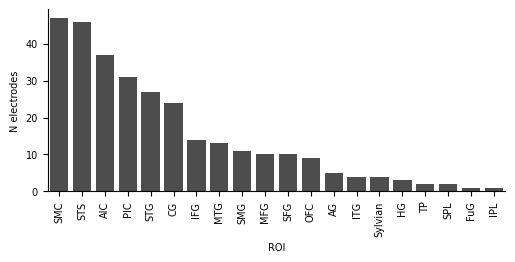

,roi,n_electrodes
13,SMC,47
17,STS,46
1,AIC,37
11,PIC,31
16,STG,27
2,CG,24
5,IFG,14
9,MTG,13
14,SMG,11
8,MFG,10


In [70]:
roi_counts = (
    coords_[['roi', 'channel']]
    # .loc[coords_.hemi=='L']
    .dropna(subset=['roi', 'channel'])
    .drop_duplicates()
    .groupby('roi', as_index=False)
    .agg(n_electrodes=('channel', 'nunique'))
    .sort_values('n_electrodes', ascending=False)
)

max_roi = roi_counts.iloc[0]['roi']
max_n = int(roi_counts.iloc[0]['n_electrodes'])
print(f"Most electrodes ROI: {max_roi} (n={max_n})")

top_n = 10
roi_counts_plot = roi_counts.head(top_n)

fig, ax = plt.subplots(figsize=(15*cm, 6*cm))
ax = sns.barplot(
    data=roi_counts,
    x='roi',
    y='n_electrodes',
    order=roi_counts['roi'],
    color='0.3',
)
ax.set_xlabel('ROI', fontdict=fontdict)
ax.set_ylabel('N electrodes', fontdict=fontdict)
ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
sns.despine()
# plt.tight_layout()
plt.show()

# fig.savefig('../img/fig4/fig4_RT_roi_counts.svg', dpi=300, bbox_inches='tight')
roi_counts.head(10)

       roi  n_electrodes
0      SMC            47
1      STS            46
2      AIC            37
3      PIC            31
4      STG            27
5       CG            24
6      IFG            14
7      MTG            13
8      SMG            11
9      MFG            10
10  OTHERS            41


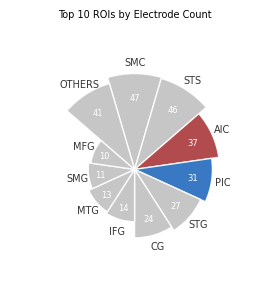

In [71]:
# --- 1. 处理数据：保留 Top N，其余归为 OTHERS ---
top_n = 10
roi_counts_sorted = roi_counts.sort_values('n_electrodes', ascending=False)

# 取出前 N 个
roi_counts_top = roi_counts_sorted.iloc[:top_n].copy()

# 计算剩余的总和
others_count = roi_counts_sorted.iloc[top_n:]['n_electrodes'].sum()

# 构造 OTHERS 行并合并
others_row = pd.DataFrame({'roi': ['OTHERS'], 'n_electrodes': [others_count]})
plot_df = pd.concat([roi_counts_top, others_row], ignore_index=True)

# --- 2. 绘制玫瑰图（极坐标条形图）---
fig, ax = plt.subplots(figsize=(8*cm, 8*cm), subplot_kw={"projection": "polar"})

values = plot_df['n_electrodes'].values
labels = plot_df['roi'].values
radii = np.sqrt(values)

n = len(values)
theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
width = 2 * np.pi / n if n > 0 else 2 * np.pi

# 颜色设置：AIC红色，PIC蓝色，其他灰色
colors = []
for lab in labels:
    if lab == "AIC":
        colors.append(red)
    elif lab == "PIC":
        colors.append(blue)
    else:
        colors.append("#C0C0C0")

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.bar(
    theta, radii, width=width, bottom=0.0,
    color=colors, edgecolor="white", linewidth=1, alpha=0.9
)

max_radius = radii.max()
ax.set_ylim(0, max_radius * 1.3)
ax.grid(False)
ax.spines["polar"].set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])

# 添加标签
for t, r, v, lab in zip(theta, radii, values, labels):
    padding = max_radius * 0.12
    ax.text(t, r + padding, f"{lab}", ha="center", va="center", fontsize=fontsize, color="#333333")
    if r > 0.45:
        ax.text(t, r * 0.75, f"{v}", ha="center", va="center", fontsize=fontsize-1, color="white")

plt.title(f'Top {top_n} ROIs by Electrode Count', fontsize=fontsize, pad=20)

plt.tight_layout()

# plt.savefig('../img/misc/top_10_rose_chart_delay.svg', dpi=300, bbox_inches='tight')

# 打印表格核对数据
print(plot_df)

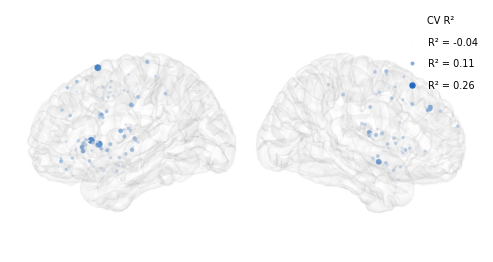

In [72]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree


roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG', 'IFG',
            'IFGs','SFGs','MFGs']

# roi_list = ['AIC', 'SMC',]

# roi_list = coords_.roi.unique().tolist()
coords = coords_[coords_.roi.isin(roi_list)][['x','y','z']].values
vals = coords_[coords_.roi.isin(roi_list)]['r2'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 99)

if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

cmap = blues
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sizes = 10 + 30 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)
# sizes = np.ones_like(vals) * 30

lh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

lh = Brain('cvs_avg35_inMNI152', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.1, size=(600*cm, 600*cm))
rh = Brain('cvs_avg35_inMNI152', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.1, size=(600*cm, 600*cm))

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

if mask_lh.any():
    _, idx = lh_tree.query(coords[mask_lh])
    proj = lh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
        cl = cmap(norm(v))[:3]
        # cl=blue
        lh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cl, lighting=False, opacity=0.95)

if mask_rh.any():
    _, idx = rh_tree.query(coords[mask_rh])
    proj = rh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
        cl = cmap(norm(v))[:3]
        # cl=blue
        rh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cl, lighting=False, opacity=0.95)

for b in (lh, rh):
    b.show_view(view='lateral', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh.screenshot(mode='rgb'))
ax2.axis('off')

# Add legend - fix size inconsistency
from matplotlib.lines import Line2D

# Create example R² values
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']

# Calculate corresponding sizes (exactly matching brain visualization)
example_sizes = 1 + 35 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

# Create legend handles - use scaling factor to match PyVista point_size
handles = []
for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    # 调整缩放因子让 matplotlib markersize 匹配 PyVista point_size
    # 通过实验找到合适的缩放因子
    markersize = size * 0.1  # 调整这个因子来匹配脑图中的大小
    
    handle = Line2D(
        [0], [0], 
        marker='o', 
        linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

# 添加图例到右侧图
ax2.legend(
    handles=handles,
    title='CV R²',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7
)

lh.close()
rh.close()

# fig.savefig(f'../img/misc/fig5_spatial_delay.svg', dpi=300, bbox_inches='tight')

Computing LH density:
  92 electrodes, 48836 vertices, density [0.004, 1.303]
Computing RH density:
  57 electrodes, 40202 vertices, density [0.009, 0.582]

Global density range: [0.0043, 1.3026]


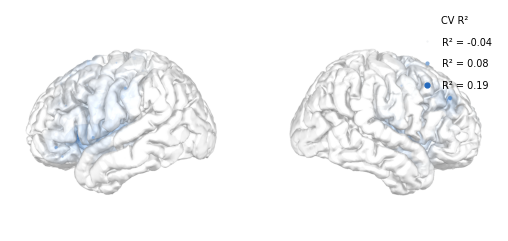

In [73]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap


# ========== 1. 数据准备 ==========
roi_list = coords_.roi.unique().tolist()

roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG', 'IFG',
            'IFGs','SFGs','MFGs']
coords = coords_[coords_.roi.isin(roi_list)][['x','y','z']].values
vals = coords_[coords_.roi.isin(roi_list)]['r2'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = blues  # 你的 blues colormap

# ========== 2. 读取表面 ==========
lh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")


mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 创建 surface trees
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

# ========== 3. 严格使用 fig4 的函数 ==========

# KDE参数设置（来自fig4）
bandwidth = 10  # 高斯核带宽（mm）
max_distance = 15  # 最大影响距离（mm）
density_opacity = 0.8  # 有密度数据区域的不透明度

def compute_density_unified(surface_coords, electrode_coords, effect_values, 
                            bandwidth=15, max_distance=30):
    """
    计算效应大小加权密度图（统一colormap版本）
    使用 cdist + np.dot 向量化计算
    """
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
    
    # 计算所有顶点到所有电极的距离矩阵 (n_vertices, n_electrodes)
    distances = cdist(surface_coords, electrode_coords)
    min_distances = distances.min(axis=1)
    mask = min_distances < max_distance
    
    # 高斯核加权
    kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
    # 使用效应大小绝对值作为权重
    density = np.dot(kernel_values, np.abs(effect_values))
    density[~mask] = 0
    
    valid_vals = density[mask & (density > 0)]
    if len(valid_vals) > 0:
        print(f"  {len(electrode_coords)} electrodes, {mask.sum()} vertices, "
              f"density [{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density, mask


def add_electrodes_to_brain(brain, coords, effect_vals, surf_tree, surf_coords,
                            color, vmin, vmax, size_min=5, size_max=30, opacity=1.0):
    """将电极点投影到pial表面并添加为球体（来自fig6逻辑）"""
    if len(coords) == 0:
        return
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]
    
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        val = np.abs(effect_vals[i])
        normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )

# ========== 4. 计算密度（使用fig4的方式） ==========
print("Computing LH density:")
lh_density, lh_mask = compute_density_unified(
    lh_coords, coords[mask_lh], vals[mask_lh],
    bandwidth=bandwidth, max_distance=max_distance
)

print("Computing RH density:")
rh_density, rh_mask = compute_density_unified(
    rh_coords, coords[mask_rh], vals[mask_rh],
    bandwidth=bandwidth, max_distance=max_distance
)

# 全局归一化（fig4方式）
all_valid = np.concatenate([
    lh_density[lh_mask & (lh_density > 0)],
    rh_density[rh_mask & (rh_density > 0)]
])
global_vmin = all_valid.min() if len(all_valid) > 0 else 0
global_vmax = all_valid.max() if len(all_valid) > 0 else 1
print(f"\nGlobal density range: [{global_vmin:.4f}, {global_vmax:.4f}]")

# ========== 5. 创建统一的 colormap（fig4方式） ==========
n_colors = 1000
colors_list = []
# 0: 无数据区域 → 完全透明（alpha=0），让底层brain表面透出
colors_list.extend([[1, 1, 1, 1]] * 1)
# 1-999: 从白色渐变到蓝色，使用独立的 density_opacity
base_color = np.array(mcolors.to_rgb(blue))  # 或者用你的 blues colormap
for i in range(1, n_colors):
    intensity = i / (n_colors - 1)
    color = (1 - intensity) * np.array([1, 1, 1]) + intensity * base_color
    colors_list.append(list(color) + [density_opacity])
custom_cmap = ListedColormap(colors_list)

# ========== 6. 可视化（严格遵循fig4方式） ==========
view_configs = [
    ('lh', lh_density, lh_mask, lh_coords, lh_tree),
    ('rh', rh_density, rh_mask, rh_coords, rh_tree),
]

brains = []
for hemi, density, dmask, surf_coords, surf_tree in view_configs:
    brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial', hemi=hemi,
        background='white', show=False,
        cortex=(0.95, 0.95, 0.95), alpha=0.2, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]

    # Layer 1: 归一化密度到 [0, n_colors-1] 用于 colormap 索引
    n_vertices = len(surf_coords)
    data_to_plot = np.zeros(n_vertices)
    has_data = dmask & (density > 0)
    if has_data.any():
        norm_density = np.clip(
            (density[has_data] - global_vmin) / (global_vmax - global_vmin), 0, 1
        )
        data_to_plot[has_data] = 1 + norm_density * (n_colors - 2)  # map to [1, n_colors-1]
    
    # 添加密度数据 — alpha=1.0 让colormap自身的alpha控制透明度
    brain.add_data(
        data_to_plot,
        hemi=hemi,
        colormap=custom_cmap,
        alpha=1.0,
        colorbar=False,
        fmin=0,
        fmax=n_colors - 1
    )
    
    # Layer 2: 叠加电极点（使用fig4的函数，颜色根据R²值变化）
    hemi_mask = mask_lh if hemi == 'lh' else mask_rh
    
    if hemi_mask.any():
        # 为每个电极单独计算颜色
        for i in range(np.sum(hemi_mask)):
            idx = np.where(hemi_mask)[0][i]
            pt = coords[idx:idx+1]
            val = vals[idx]
            normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
            color = cmap(normalized)[:3]
            size = 5 + 30 * normalized
            
            cloud = pv.PolyData(pt)
            brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=float(size),
                color=color,
                lighting=False,
                smooth_shading=False,
                opacity=0.95,
            )
    
    brain.show_view(view="lateral", distance=400)
    brains.append(brain)

# ========== 7. 截图并绘制 matplotlib 图形（fig4方式） ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]}
)

ax1.imshow(brains[0].screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(brains[1].screenshot(mode="rgb"))
ax2.axis("off")

# 图例（fig3原有）
from matplotlib.lines import Line2D
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']
example_sizes = 5 + 30 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

handles = []
for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    markersize = size * 0.1
    handle = Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

ax2.legend(
    handles=handles, title='CV R²', loc='upper right',
    frameon=False, borderaxespad=0.2, handletextpad=0.6,
    labelspacing=1.2, fontsize=7, title_fontsize=7
)

for b in brains:
    b.close()

# fig.savefig(f'../img/misc/fig5_spatial_delay.svg', dpi=300, bbox_inches='tight')

Computing LH density:
  92 electrodes, 48836 vertices, density [0.002, 1.127]
Computing RH density:
  57 electrodes, 40202 vertices, density [0.002, 0.439]

Global density range: [0.0017, 1.1266]
lh lateral: focal_point=[-38.6  20.6  -2.5], n_electrodes=92
rh lateral: focal_point=[39.5 22.5  0.9], n_electrodes=57


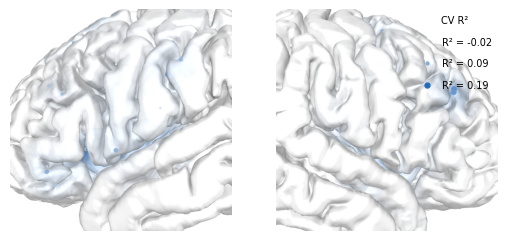

In [74]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap


# ========== 1. 数据准备（聚焦到指定ROI） ==========
roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG', 'IFG',
            'IFGs','SFGs','MFGs']
coords = coords_[coords_.roi.isin(roi_list)][['x', 'y', 'z']].values
vals = coords_[coords_.roi.isin(roi_list)]['r2'].values

vmin = np.nanpercentile(vals, 5)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = blues

# ========== 2. 读取表面 ==========
lh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 创建 surface trees
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

# ========== 3. 核心函数 ==========
bandwidth = 8
max_distance = 15
density_opacity = 0.9

def compute_density_unified(surface_coords, electrode_coords, effect_values, 
                            bandwidth=15, max_distance=30):
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
    
    distances = cdist(surface_coords, electrode_coords)
    min_distances = distances.min(axis=1)
    mask = min_distances < max_distance
    
    kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
    density = np.dot(kernel_values, np.abs(effect_values))
    density[~mask] = 0
    
    valid_vals = density[mask & (density > 0)]
    if len(valid_vals) > 0:
        print(f"  {len(electrode_coords)} electrodes, {mask.sum()} vertices, "
              f"density [{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density, mask


def add_electrodes_to_brain(brain, coords, effect_vals, surf_tree, surf_coords,
                            vmin, vmax, size_min=10, size_max=50, opacity=1.0):
    """将电极点投影到pial表面并添加为球体（颜色根据R²值变化）"""
    if len(coords) == 0:
        return
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]
    
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        val = np.abs(effect_vals[i])
        normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        color = cmap(normalized)[:3]
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )


def get_roi_center(coords_subset):
    """计算ROI电极的中心点作为相机焦点"""
    if len(coords_subset) == 0:
        return None
    return np.mean(coords_subset, axis=0)

# ========== 4. 计算密度 ==========
print("Computing LH density:")
lh_density, lh_mask = compute_density_unified(
    lh_coords, coords[mask_lh], vals[mask_lh],
    bandwidth=bandwidth, max_distance=max_distance
)

print("Computing RH density:")
rh_density, rh_mask = compute_density_unified(
    rh_coords, coords[mask_rh], vals[mask_rh],
    bandwidth=bandwidth, max_distance=max_distance
)

# 全局归一化
all_valid = np.concatenate([
    lh_density[lh_mask & (lh_density > 0)],
    rh_density[rh_mask & (rh_density > 0)]
])
global_vmin = all_valid.min() if len(all_valid) > 0 else 0
global_vmax = all_valid.max() if len(all_valid) > 0 else 1
print(f"\nGlobal density range: [{global_vmin:.4f}, {global_vmax:.4f}]")

# ========== 5. 创建统一的 colormap ==========
n_colors = 1000
colors_list = []
colors_list.extend([[1, 1, 1, 1]] * 1)
base_color = np.array(mcolors.to_rgb(blue))
for i in range(1, n_colors):
    intensity = i / (n_colors - 1)
    color = (1 - intensity) * np.array([1, 1, 1]) + intensity * base_color
    colors_list.append(list(color) + [density_opacity])
custom_cmap = ListedColormap(colors_list)

# ========== 6. 可视化（聚焦视图模式） ==========

# 定义视图配置：(hemi, view_type, surface_coords, surface_tree, electrode_mask)
view_configs = [
    ('lh', 'lateral', lh_coords, lh_tree, mask_lh),
    ('rh', 'lateral', rh_coords, rh_tree, mask_rh),
]

brains = []
for hemi, view, surf_coords, surf_tree, hemi_mask in view_configs:
    brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial', hemi=hemi,
        background='white', show=False,
        cortex=(0.95, 0.95, 0.95), alpha=0.2, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]

    # Layer 1: 密度数据
    n_vertices = len(surf_coords)
    data_to_plot = np.zeros(n_vertices)
    has_data = (lh_mask if hemi == 'lh' else rh_mask) & ((lh_density if hemi == 'lh' else rh_density) > 0)
    
    if has_data.any():
        density = lh_density if hemi == 'lh' else rh_density
        norm_density = np.clip(
            (density[has_data] - global_vmin) / (global_vmax - global_vmin), 0, 1
        )
        data_to_plot[has_data] = 1 + norm_density * (n_colors - 2)
    
    brain.add_data(
        data_to_plot,
        hemi=hemi,
        colormap=custom_cmap,
        alpha=1.0,
        colorbar=False,
        fmin=0,
        fmax=n_colors - 1
    )
    
    # Layer 2: 叠加电极点
    if hemi_mask.any():
        add_electrodes_to_brain(
            brain, 
            coords[hemi_mask], 
            vals[hemi_mask],
            surf_tree, 
            surf_coords,
            vmin, 
            vmax
        )
    
    # ========== 关键：设置聚焦视图 ==========
    coords_hemi = coords[hemi_mask] if hemi_mask.any() else np.array([])
    focal_point = get_roi_center(coords_hemi)
    
    if focal_point is not None:
        # 基础视图设置
        brain.show_view(view=view, distance=270)  # 距离缩短以聚焦
        
        # 设置相机焦点到ROI中心
        brain._renderer.plotter.camera.focal_point = focal_point
        
        # 根据视图类型设置相机位置
        if view == 'lateral':
            # lateral视图：相机在左右侧
            brain._renderer.plotter.camera.position = (
                focal_point[0] - 200 if hemi == 'lh' else focal_point[0] + 200,
                focal_point[1],
                focal_point[2]
            )
        else:  # medial
            # medial视图：相机在内侧
            brain._renderer.plotter.camera.position = (
                focal_point[0] + 200 if hemi == 'lh' else focal_point[0] - 200,
                focal_point[1],
                focal_point[2]
            )
        
        print(f"{hemi} {view}: focal_point={focal_point.round(1)}, "
              f"n_electrodes={len(coords_hemi)}")
    else:
        # 没有电极时的默认视图
        brain.show_view(view=view, distance=400)
    
    brains.append(brain)

# ========== 7. 截图并绘制 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]}
)

ax1.imshow(brains[0].screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(brains[1].screenshot(mode="rgb"))
ax2.axis("off")

# 图例
from matplotlib.lines import Line2D
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']
example_sizes = 5 + 30 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

handles = []

for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    markersize = size * 0.1
    handle = Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

ax2.legend(
    handles=handles, title='CV R²', loc='upper right',
    frameon=False, borderaxespad=0.2, handletextpad=0.6,
    labelspacing=1.2, fontsize=7, title_fontsize=7
)

for b in brains:
    b.close()

plt.show()

lh lateral: focal_point=[-38.6  20.6  -2.5], n_electrodes=92
rh lateral: focal_point=[39.5 22.5  0.9], n_electrodes=57


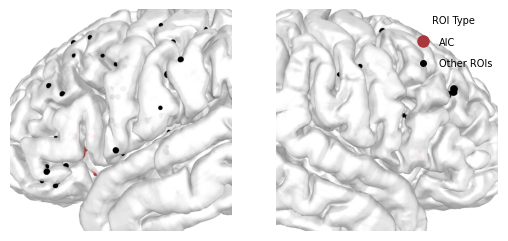

In [75]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D


# ========== 1. 数据准备（聚焦到指定ROI，保留ROI标签） ==========
roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG', 'IFG',
            'IFGs', 'SFGs', 'MFGs']

# 筛选数据并保留ROI标签
roi_data = coords_[coords_.roi.isin(roi_list)]
coords = roi_data[['x', 'y', 'z']].values
vals = roi_data['r2'].values
roi_labels = roi_data['roi'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ========== 2. 读取表面 ==========
lh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)


# ========== 3. 核心函数 ==========
def add_electrodes_to_brain(brain, coords, effect_vals, roi_vals, surf_tree, surf_coords,
                            vmin, vmax, size_min=20, size_max=60, opacity=1.0):
    """将电极点投影到pial表面并添加为球体
    AIC电极显示红色，其他电极显示黑色
    """
    if len(coords) == 0:
        return
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]

    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        val = np.abs(effect_vals[i])
        roi = roi_vals[i]

        normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)

        if roi == 'AIC':
            color = red
        else:
            color = 'black'

        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )


def get_roi_center(coords_subset):
    """计算ROI电极的中心点作为相机焦点"""
    if len(coords_subset) == 0:
        return None
    return np.mean(coords_subset, axis=0)


# ========== 4. 可视化 ==========
view_configs = [
    ('lh', 'lateral', lh_coords, lh_tree, mask_lh),
    ('rh', 'lateral', rh_coords, rh_tree, mask_rh),
]

brains = []
for hemi, view, surf_coords, surf_tree, hemi_mask in view_configs:
    brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial', hemi=hemi,
        background='white', show=False,
        cortex=(0.95, 0.95, 0.95), alpha=0.9, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]

    # Layer 1: 电极点（AIC=红色大点，其他=黑色小点）
    if hemi_mask.any():
        add_electrodes_to_brain(
            brain,
            coords[hemi_mask],
            vals[hemi_mask],
            roi_labels[hemi_mask],
            surf_tree,
            surf_coords,
            vmin,
            vmax,
            size_min=20,
            size_max=60
        )

    # 设置聚焦视图
    coords_hemi = coords[hemi_mask] if hemi_mask.any() else np.array([])
    focal_point = get_roi_center(coords_hemi)

    if focal_point is not None:
        brain.show_view(view=view, distance=270)
        brain._renderer.plotter.camera.focal_point = focal_point

        if view == 'lateral':
            brain._renderer.plotter.camera.position = (
                focal_point[0] - 200 if hemi == 'lh' else focal_point[0] + 200,
                focal_point[1],
                focal_point[2]
            )
        else:
            brain._renderer.plotter.camera.position = (
                focal_point[0] + 200 if hemi == 'lh' else focal_point[0] - 200,
                focal_point[1],
                focal_point[2]
            )

        print(f"{hemi} {view}: focal_point={focal_point.round(1)}, "
              f"n_electrodes={len(coords_hemi)}")
    else:
        brain.show_view(view=view, distance=400)

    brains.append(brain)

# ========== 5. 截图并绘制 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]}
)

ax1.imshow(brains[0].screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(brains[1].screenshot(mode="rgb"))
ax2.axis("off")

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=red, markeredgecolor=red,
           markersize=8, label='AIC'),
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='black', markeredgecolor='black',
           markersize=4, label='Other ROIs'),
]
ax2.legend(
    handles=handles, title='ROI Type', loc='upper right',
    frameon=False, borderaxespad=0.2, handletextpad=0.6,
    labelspacing=1.2, fontsize=7, title_fontsize=7
)

for b in brains:
    b.close()

plt.show()


Computing LH density on pial surface:
  72 electrodes, 32792 vertices, density [0.004, 1.119]
Computing RH density on pial surface:
  46 electrodes, 26042 vertices, density [0.003, 0.336]

Global density range (p10, p80): [0.0092, 0.2797]
lh lateral: focal_point=[-13.9  39.6   7.9], n_electrodes=72
rh lateral: focal_point=[12.3 38.8 11.8], n_electrodes=46


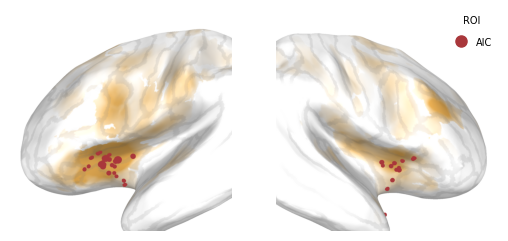

In [79]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap


# ========== 1. 数据准备（聚焦到指定ROI，保留ROI标签） ==========
roi_list = ['AIC', 'SMC', 'SFG', 'MFG', 'IFG',
            'IFGs', 'SFGs', 'MFGs']

# 筛选数据并保留ROI标签
roi_data = coords_[coords_.roi.isin(roi_list)]
coords = roi_data[['x', 'y', 'z']].values
vals = roi_data['r2'].values
roi_labels = roi_data['roi'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = sns.light_palette('#0E723B', as_cmap=True)


# ========== 2. 读取表面（读取pial用于投影，inflated用于显示） ==========
lh_coords_pial, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_coords_pial, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")

# 读取inflated表面（用于显示）
lh_coords_inflated, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.inflated")
rh_coords_inflated, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.inflated")

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# 创建pial surface trees（用于投影计算）
lh_tree_pial = cKDTree(lh_coords_pial)
rh_tree_pial = cKDTree(rh_coords_pial)

# 创建inflated surface trees
lh_tree_inflated = cKDTree(lh_coords_inflated)
rh_tree_inflated = cKDTree(rh_coords_inflated)

# ========== 3. 核心函数 ==========
bandwidth = 8
max_distance = 12
density_opacity = 0.8

def compute_density_unified(surface_coords, electrode_coords, effect_values, 
                            bandwidth=15, max_distance=30):
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
    
    distances = cdist(surface_coords, electrode_coords)
    min_distances = distances.min(axis=1)
    mask = min_distances < max_distance
    
    kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
    density = np.dot(kernel_values, np.abs(effect_values))
    density[~mask] = 0
    
    valid_vals = density[mask & (density > 0)]
    if len(valid_vals) > 0:
        print(f"  {len(electrode_coords)} electrodes, {mask.sum()} vertices, "
              f"density [{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density, mask


def add_electrodes_to_brain_inflated(brain, coords, effect_vals, roi_vals, 
                                      tree_pial, tree_inflated,
                                      coords_pial, coords_inflated,
                                      vmin, vmax, size_min=20, size_max=60, opacity=1.0):
    """将电极点投影到inflated表面并添加为球体
    AIC电极显示红色，其他电极显示黑色
    """
    if len(coords) == 0:
        return
    
    # 先在pial表面找到最近顶点索引
    _, indices_pial = tree_pial.query(coords)
    
    # 使用相同的顶点索引在inflated表面上获取坐标
    coords_on_inflated = coords_inflated[indices_pial]
    
    for i in range(len(coords_on_inflated)):
        pt = coords_on_inflated[i:i+1]
        val = np.abs(effect_vals[i])
        roi = roi_vals[i]
        
        normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        
        color = red
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )


def get_roi_center_inflated(coords_subset, tree_pial, coords_inflated):
    """计算ROI电极在inflated表面上的中心点"""
    if len(coords_subset) == 0:
        return None
    
    _, indices = tree_pial.query(coords_subset)
    coords_inflated_subset = coords_inflated[indices]
    return np.mean(coords_inflated_subset, axis=0)

# ========== 4. 计算密度（在pial表面上计算，然后映射到inflated显示） ==========
print("Computing LH density on pial surface:")
lh_density, lh_mask_surf = compute_density_unified(
    lh_coords_pial, coords[mask_lh], vals[mask_lh],
    bandwidth=bandwidth, max_distance=max_distance
)

print("Computing RH density on pial surface:")
rh_density, rh_mask_surf = compute_density_unified(
    rh_coords_pial, coords[mask_rh], vals[mask_rh],
    bandwidth=bandwidth, max_distance=max_distance
)

# 全局归一化：用百分位数裁剪，让色彩范围更集中（同 fig2 方式）
all_valid = np.concatenate([
    lh_density[lh_mask_surf & (lh_density > 0)],
    rh_density[rh_mask_surf & (rh_density > 0)]
])
if len(all_valid) > 0:
    global_vmin = float(np.percentile(all_valid, 2))
    global_vmax = float(np.percentile(all_valid, 96))
else:
    global_vmin, global_vmax = 0.0, 1.0
print(f"\nGlobal density range (p10, p80): [{global_vmin:.4f}, {global_vmax:.4f}]")

# ========== 5. 创建统一的 colormap ==========
n_colors = 1000
colors_list = [[1, 1, 1, 1]]  # index 0: 无数据 → 白色
base_color = np.array(mcolors.to_rgb('#DC9627'))
for i in range(1, n_colors):
    intensity = i / (n_colors - 1)
    color = (1 - intensity) * np.array([1, 1, 1]) + intensity * base_color
    colors_list.append(list(color) + [density_opacity])
custom_cmap = ListedColormap(colors_list)

# ========== 6. 可视化（Inflated表面 + 聚焦视图） ==========
view_configs = [
    ('lh', 'lateral', lh_coords_inflated, lh_tree_pial, lh_tree_inflated, lh_coords_pial, mask_lh),
    ('rh', 'lateral', rh_coords_inflated, rh_tree_pial, rh_tree_inflated, rh_coords_pial, mask_rh),
]

brains = []

for hemi, view, surf_coords, tree_pial, tree_inflated, coords_pial, hemi_mask in view_configs:
    # 使用inflated表面创建Brain
    brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='inflated', hemi=hemi,
        background='white', show=False,
        cortex=(0.95, 0.95, 0.95), alpha=0.8, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]

    # Layer 1: 密度数据
    n_vertices = len(surf_coords)
    data_to_plot = np.zeros(n_vertices)
    has_data = (lh_mask_surf if hemi == 'lh' else rh_mask_surf) & \
               ((lh_density if hemi == 'lh' else rh_density) > 0)
    
    if has_data.any():
        density = lh_density if hemi == 'lh' else rh_density
        norm_density = np.clip(
            (density[has_data] - global_vmin) / (global_vmax - global_vmin + 1e-12), 0, 1
        )
        data_to_plot[has_data] = 1 + norm_density * (n_colors - 2)
    
    brain.add_data(
        data_to_plot,
        hemi=hemi,
        colormap=custom_cmap,
        alpha=1.0,
        colorbar=False,
        fmin=0,
        fmax=n_colors - 1
    )
    
    # Layer 2: 添加脑区边界
    brain.add_annotation(
        'aparc.a2009s',
        borders=True,
        color='gray',
        alpha=0.4,
    )
    for actor in brain._renderer.plotter.actors.values():
        prop = actor.GetProperty()
        if prop.GetRepresentation() == 1:
            prop.SetLineWidth(0.1)
    
    # Layer 3: 叠加AIC电极点
    if hemi_mask.any():
        aic_mask = roi_labels[hemi_mask] == 'AIC'
        if aic_mask.any():
            add_electrodes_to_brain_inflated(
                brain, 
                coords[hemi_mask][aic_mask], 
                vals[hemi_mask][aic_mask],
                roi_labels[hemi_mask][aic_mask],
                tree_pial, tree_inflated,
                coords_pial, surf_coords,
                vmin, vmax,
                size_min=20,
                size_max=50
            )
    
    # 设置聚焦视图
    coords_hemi = coords[hemi_mask] if hemi_mask.any() else np.array([])
    focal_point = get_roi_center_inflated(coords_hemi, tree_pial, surf_coords)
    
    if focal_point is not None:
        brain.show_view(view=view, distance=270)
        brain._renderer.plotter.camera.focal_point = focal_point
        
        distance = 320
        if view == 'lateral':
            brain._renderer.plotter.camera.position = (
                focal_point[0] - distance if hemi == 'lh' else focal_point[0] + distance,
                focal_point[1],
                focal_point[2]
            )
        else:
            brain._renderer.plotter.camera.position = (
                focal_point[0] + distance if hemi == 'lh' else focal_point[0] - distance,
                focal_point[1],
                focal_point[2]
            )
        
        print(f"{hemi} {view}: focal_point={focal_point.round(1)}, "
              f"n_electrodes={len(coords_hemi)}")
    else:
        brain.show_view(view=view, distance=400)
    
    brains.append(brain)

# ========== 7. 截图并绘制 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]}
)

ax1.imshow(brains[0].screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(brains[1].screenshot(mode="rgb"))
ax2.axis("off")

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=red, markeredgecolor=red,
           markersize=8, label='AIC'),
]
ax2.legend(
    handles=handles, title='ROI', loc='upper right',
    frameon=False, borderaxespad=0.2, handletextpad=0.6,
    labelspacing=1.2, fontsize=7, title_fontsize=7
)

for b in brains:
    b.close()

plt.show()


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2015543/447752931.py:43: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  line = sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2015543/447752931.py:43: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  line = sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2015543/447752931.py:43: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  line = sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2015543/447752931.py:43: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  line = sns.lineplot(


<Figure size 640x480 with 0 Axes>

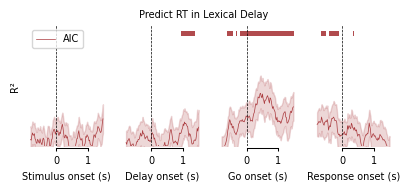

In [81]:
sig = rt_subset[rt_subset['mask'] == True].copy()

# 按 channel 分组，检查每个 channel 是否至少有一个显著时间点 (mask == True)
sig_channels = sig.groupby('channel').size() > 0
sig_channels = sig_channels[sig_channels].index.tolist()

sig_rt = rt_subset[
    rt_subset['channel'].isin(sig_channels)
].copy()

rois = ['AIC']
palette=[red, blue]

# rois = sig.roi.unique()
condition = 'Repeat'
subset = sig_rt[(sig_rt.description==condition)]

plt.subplots_adjust(wspace=0)

ymax, pad, bar_h = 0.2, 0.01, 0.01
sig_threshold = 0.1  # 1%

phases = ['Stimulus', 'Delay' ,'Go', 'Response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*len(phases)*cm, 4*cm))

for (ax, phase) in zip(axes, phases):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True

    g = subset[(subset.phase == phase) & (subset.roi.isin(rois))].groupby('channel')['r2']

    picks = (
        g.min().ge(-1) &   
        g.max().le(1) &    
        g.max().gt(0)     
    )
    
    picks = picks[picks].index
    palette_map = dict(zip(rois, palette))

    line = sns.lineplot(
        data=subset[(subset.phase == phase) & (subset.channel.isin(picks))],
        x='time',
        y='r2',
        ax=ax,
        legend=legend,
        hue='roi',
        hue_order=rois,
        palette=palette,
        lw=0.5
    )

    ylabel = 'R²' if ax == axes[0] else ''
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)   
        
    ymin = 0
    bar_base = ymax + pad
    gap = bar_h * 0.1 
    
    for i, roi in enumerate(rois):
        sig_ratio = subset[(subset.phase == phase) & (subset.roi == roi)].sort_values('time')
        sig_ratio = sig_ratio.groupby('time')['mask'].mean()
        aggregated_mask = sig_ratio >= sig_threshold
    
        if aggregated_mask.any():
            y0 = bar_base + i * (bar_h + gap)
            ax.fill_between(
                sig_ratio.index.values,
                y0,
                y0 + bar_h,
                where=aggregated_mask.values,
                color=palette_map[roi],
                alpha=0.9,
                step='mid',
                linewidth=0
            )
    
    # 让 ylim 包含所有 bar
    ax.set_ylim(ymin, bar_base + len(rois) * (bar_h + gap) + bar_h)

for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    # ax.axhline(y=-0.1, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    # ax.set_ylim(ymin, ymax + pad + bar_h + 0.02)

plt.suptitle(f'Predict RT in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/misc/fig5_predict_rt_temporal_ROI.svg', dpi=300, bbox_inches='tight')
plt.show()


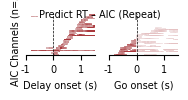

In [ ]:
import xarray as xr

roi = 'AIC'
phases = ['Delay', 'Go',]
cmap = reds

# --- 1. 只保留在 Delay phase, time >= 0 有显著时间点的 channels ---
sig = rt_subset[
    (rt_subset['mask'] == True) &
    (rt_subset['roi'] == roi) &
    (rt_subset['phase'] == 'Delay') &
    (rt_subset['time'] >= 0.0)
].copy()
sig_channels = sig['channel'].unique().tolist()

subset = rt_subset[
    (rt_subset['channel'].isin(sig_channels)) &
    (rt_subset['description'] == 'Repeat') &
    (rt_subset['roi'] == roi)
].copy()

# 非显著时间点置为 NaN
subset.loc[~subset['mask'], 'r2'] = np.nan

# --- 2. 各 phase 分别按第一个显著时间点排序 ---
def get_sorted_channels(phase_name, sig_channels, subset, time_min=None, time_max=None):
    phase_data = subset[subset['phase'] == phase_name]
    if time_min is not None:
        phase_data = phase_data[phase_data['time'] >= time_min]
    if time_max is not None:
        phase_data = phase_data[phase_data['time'] <= time_max]
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data['channel'] == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    return [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]

phase_sorted_channels = {
    'Delay': get_sorted_channels('Delay', sig_channels, subset, time_min=0.0),
    'Go':    get_sorted_channels('Go',    sig_channels, subset),
}

n_channels = len(sig_channels)

# --- 3. 绘图 ---
fig, axes = plt.subplots(
    nrows=1, ncols=len(phases),
    figsize=(2.5 * len(phases) * cm, float(0.01 * n_channels * cm + 1 * cm))
)

for ax, phase in zip(axes, phases):
    sorted_channels = phase_sorted_channels[phase]
    phase_data = subset[subset['phase'] == phase]

    if len(phase_data) == 0 or len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    phase_data_filtered = phase_data[phase_data['channel'].isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot_table(
        index='channel', columns='time', values='r2', aggfunc='mean'
    )
    pivot_data = pivot_data.reindex(index=sorted_channels)

    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns.astype(float)},
        dims=['channel', 'time']
    )

    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01
    time_edges = np.concatenate((
        [time_values[0] - step / 2],
        time_values[:-1] + step / 2,
        [time_values[-1] + step / 2]
    ))
    channel_edges = np.arange(n_channels + 1)

    T, C = np.meshgrid(time_edges, channel_edges)

    if phase == 'Go':
        # split at time 0: pre-0 full alpha, post-0 faded
        vals_arr = da.values
        time_mask_pre = (time_values <= 0.0)  # shape (n_time,)
        pre = np.where(time_mask_pre[np.newaxis, :], vals_arr, np.nan)
        post = np.where(~time_mask_pre[np.newaxis, :], vals_arr, np.nan)

        ax.pcolormesh(
            T, C, pre,
            cmap=cmap, vmin=0, vmax=0.4,
            shading='auto', rasterized=True, alpha=1.0
        )
        ax.pcolormesh(
            T, C, post,
            cmap=cmap, vmin=0, vmax=0.4,
            shading='auto', rasterized=True, alpha=0.3
        )
    else:
        ax.pcolormesh(
            T, C, da.values,
            cmap=cmap, vmin=0, vmax=0.4,
            shading='auto', rasterized=True
        )

    sns.despine(ax=ax, offset=0, trim=False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['-1', '0', '1'], fontsize=7)
    ax.set_yticks([])
    ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, n_channels)

    if ax == axes[0]:
        ax.set_ylabel(f'{roi} Channels (n={n_channels})', fontsize=7)

plt.suptitle(f'Predict RT – {roi} (Repeat)', fontsize=7)
plt.savefig(f'../img/misc/fig5_predict_rt_heatmap_{roi}.svg', dpi=300, bbox_inches='tight')
plt.show()

# Show that SMC also have delay

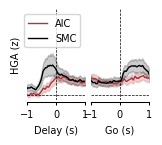

In [29]:
rois = ['AIC', 'SMC']

colors = [red, 'black']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.subject!='D0007')
    & (HGAs.task!='Lexicalnodelay')
    # & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
    & (HGAs.roi.isin(rois))
    & (HGAs.subject!='D0121')
]

phases = ['delay', 'go']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2*len(phases)*cm, 3*cm),)

plt.subplots_adjust(wspace=0.1)

# Create plots with proper labels for legend
for (ax, phase) in zip(axes, phases):
    
    legend = True if ax == axes[-2] else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1
    )
    
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    ax.set_xlim(-1, 1)
    
    if ax != axes[0]:
        # ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

plt.savefig('../img/fig2/fig2_temporal_LS_{}.svg'.format('_'.join(rois)), dpi=300, bbox_inches='tight')
plt.show()

# Decode

In [123]:
from scipy.ndimage import gaussian_filter1d

ref = 'bipolar'

task = 'PhonemeSequence'
decode_type = 'articulator'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 2  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
# scores = scores[scores.description=='Decision']
scores = scores[scores.phoneme=='1']
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,phoneme,datatype,band
0,-0.30,0,0.243962,0.260714,0.194030,AIC,Delay,Left,Repeat,1,(decode)(resolved)articulator,highgamma
1,-0.28,0,0.224704,0.235952,0.114428,AIC,Delay,Left,Repeat,1,(decode)(resolved)articulator,highgamma
2,-0.26,0,0.213420,0.247381,0.004975,AIC,Delay,Left,Repeat,1,(decode)(resolved)articulator,highgamma
3,-0.24,0,0.214795,0.253095,0.273632,AIC,Delay,Left,Repeat,1,(decode)(resolved)articulator,highgamma
4,-0.22,0,0.226005,0.237143,0.393035,AIC,Delay,Left,Repeat,1,(decode)(resolved)articulator,highgamma


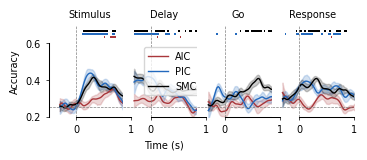

In [135]:
hue_order = ['AIC', 'PIC','SMC']
hemis = ['Left']
phases = ['Stimulus', 'Delay', 'Go', 'Response']

fig, axes = plt.subplots(1, len(phases), figsize=(2.5*len(phases)*cm, 3*len(hemis)*cm))

plt.subplots_adjust(wspace=-0.1)

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 0.6, 0.03, 0.01
chance = 1/4
ymin = 0.2

colors = [red, blue,'black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 1 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 1)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.01)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.5, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[1].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')

fig.savefig(f'../img/fig3/fig3_{task}_{decode_type}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
# load decoding channels
PHONEME_PATH = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(PHONEME_PATH, 'decoding(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []
coords = HGAs.drop(columns=['time', 'value']).drop_duplicates()

for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

,channel,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
18,D0035_LAI2-3,False,AIC,L,D0035,Repeat,PhonemeSequence,go,sound,ctx_lh_G_insular_short,-38.957102,25.505425,-19.628099
1145,D0035_LAI2-3,True,AIC,L,D0035,Repeat,PhonemeSequence,go,sound,ctx_lh_G_insular_short,-38.957102,25.505425,-19.628099
17,D0035_LAI2-3,False,AIC,L,D0035,Repeat,PhonemeSequence,response,sound,ctx_lh_G_insular_short,-38.957102,25.505425,-19.628099
753,D0035_LAI2-3,True,AIC,L,D0035,Repeat,PhonemeSequence,response,sound,ctx_lh_G_insular_short,-38.957102,25.505425,-19.628099
7,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,stimulus,sound,ctx_lh_S_circular_insula_sup,-34.781228,20.488790,-9.816074


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot


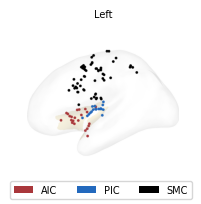

In [166]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial"
lh_infl_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    subject='cvs_avg35_inMNI152',
    hemi='lh',
    surf='inflated',
    subjects_dir=recon_dir,
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',  
    surf_name='pial',
    hemi='lh', subjects_dir=recon_dir
)

insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]

for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=450)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
# fig.savefig(f'../img/fig3/fig3_{task}_spatial.svg', dpi=300, bbox_inches='tight')
plt.show()

## Confusion matrix

In [1]:
import sys, os, importlib.util

src_dir = '/hpc/home/ns458/coganlab/nanlinshi/insula/src'   # 或 /hpc/group/... 任一皆可
proj_root = os.path.dirname(src_dir)

# 1) 先把 src/ 和 project root 放到 sys.path 最前
for p in (src_dir, proj_root):
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

# 2) 清掉可能已缓存的半成品，避免重跑 cell 时拿到旧的
for m in ['src', 'src.run_decoding', 'src.decoder', 'decoder', 'run_decoding']:
    sys.modules.pop(m, None)

# 3) 先手动 load decoder.py 成顶层模块 `decoder`,
#    这样 run_decoding.py 里的 `from decoder import ...` 一定能找到
spec = importlib.util.spec_from_file_location('decoder', os.path.join(src_dir, 'decoder.py'))
decoder_mod = importlib.util.module_from_spec(spec)
sys.modules['decoder'] = decoder_mod
spec.loader.exec_module(decoder_mod)

# 4) 现在可以正常 import
from src.run_decoding import load_roi_data

In [2]:
import sys, os
 
# project root (for `src.xxx`) + src/ (for bare `decoder` import inside run_decoding.py)
proj_root = os.path.abspath('..')
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'src'))

from src.run_decoding import load_roi_data

bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS'
ref = 'bipolar'
roi = 'AICl'
description = 'Repeat'
phase = 'Delay'
band = 'highgamma'
datatype = 'articulator'
tmin = 0
tmax = 1

X, y, _ = load_roi_data(bids_root, ref, roi, description, phase, band, datatype, tmin, tmax)

In [3]:
from src.decoder import get_cv_predict
from ieeg.calc.oversample import MinimumNaNSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from mne.decoding import Vectorizer
from sklearn.metrics import confusion_matrix
import numpy as np

# 选择要用的 ROI 数据文件（这里取第一个）。
X_np = np.asarray(X[0])
y_np = np.asarray(y[0])
print(f"Loaded X shape={X_np.shape}, y shape={y_np.shape}, unique labels={np.unique(y_np)}")

# 交叉验证与 decoder（沿用默认 MinimumNaNSplit + PCA+SVC，sample_fold 在 get_cv_predict 内部被调用）
cv = MinimumNaNSplit(n_splits=10, n_repeats=5)
decoder = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    PCA(n_components=0.85, random_state=42),
    SVC(kernel="linear", random_state=42),
)

# Out-of-fold 预测
y_pred = get_cv_predict(
    X_np,
    y_np,
    cv,
    decoder,
    n_jobs=-1,
)
acc = (y_pred == y_np).mean()
# 映射顺序 0:dorsal, 1:high_vowel, 2:labial, 3:low_vowel
label_names = ['dorsal', 'high', 'labial', 'low']
label_ids = list(range(len(label_names)))  # [0,1,2,3]

conf_mat = confusion_matrix(y_np, y_pred, labels=label_ids, normalize="true")
conf_mat_counts = confusion_matrix(y_np, y_pred, labels=label_ids, normalize=None)
print(f"CV accuracy (mean OOF): {acc:.3f}")
conf_mat

Loaded X shape=(205, 28, 128), y shape=(205,), unique labels=[0 1 2 3]


CV folds:   0%|          | 0/50 [00:00<?, ?it/s]

CV folds: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s] 


CV accuracy (mean OOF): 0.254


array([[0.16666667, 0.27083333, 0.35416667, 0.20833333],
       [0.2       , 0.41818182, 0.18181818, 0.2       ],
       [0.24074074, 0.27777778, 0.22222222, 0.25925926],
       [0.25      , 0.35416667, 0.20833333, 0.1875    ]])

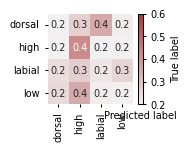

In [12]:
fig, ax = plt.subplots(figsize=(3.5*cm, 3*cm))

a = sns.heatmap(
    conf_mat,
    annot=True,
    fmt=".1f",
    cmap=reds,
    annot_kws={"size": 7},
    cbar=True,
    vmin=0.2,
    vmax=0.6,
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)

ax.set_xlabel("Predicted label", fontsize=7)
ax.set_ylabel("True label", fontsize=7)

plt.savefig(f'img/misc/confusion_matrix_delay_{roi}.svg',dpi=300,bbox_inches='tight')